# Notebook 15 — Probabilistic Variational Autoencoder (VAE)

**A generative model for uncertainty.** Every detector so far produces a
**binary** verdict (score > threshold). An NIS2 operator, however, needs to
*triage*: is this alarm strong or marginal? The **variational autoencoder**
(Kingma & Welling, 2014; the $\beta$-VAE of Higgins et al., 2017) learns a
latent distribution from which we can estimate a **reconstruction probability**
by Monte Carlo (An & Cho, 2015), so that every alarm comes with an
**uncertainty band**.

- Same *footprint* as the Dense-AE, keeping the edge comparison fair.
- Score = $-\mathbb{E}_{z\sim q(z|x)}[\log p(x|z)]$, estimated with $L$ samples.
- Uncertainty = standard deviation of the score across the $L$ samples.

> The protocol mirrors NB04 (via `tfg_common`): the model trains on
> `train_clean`, and the threshold together with $(W,K)$ are calibrated on the
> validation set alone.

## 0. Setup

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score
from sklearn.isotonic import IsotonicRegression
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11
import tfg_common as C

d = C.build_matrices(mode='full')
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_val, y_test = d['y_val'], d['y_test']
n_features = d['n_features']
print('Data:', X_train.shape)

Data: (1300061, 17)


## 1. $\beta$-VAE architecture

In [2]:
LATENT = 4; BETA = 1.0
LOGVAR_CLIP = 6.0   # cap logvar so exp(logvar) can't overflow on RobustScaler outliers

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        logvar = tf.clip_by_value(logvar, -LOGVAR_CLIP, LOGVAR_CLIP)
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps   # reparameterization trick

class VAE(keras.Model):
    def __init__(self, n_features, latent=4, beta=1.0):
        super().__init__()
        self.beta = beta
        inp = keras.Input((n_features,))
        h = layers.Dense(64, activation='relu')(inp)
        h = layers.Dense(32, activation='relu')(h)
        mu = layers.Dense(latent, name='mu')(h)
        logvar = layers.Dense(latent, name='logvar')(h)
        self.encoder = keras.Model(inp, [mu, logvar], name='encoder')
        zin = keras.Input((latent,))
        h = layers.Dense(32, activation='relu')(zin)
        h = layers.Dense(64, activation='relu')(h)
        out = layers.Dense(n_features, activation='linear')(h)
        self.decoder = keras.Model(zin, out, name='decoder')
        self.sampling = Sampling()
        self.loss_tracker = keras.metrics.Mean(name='loss')

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, x):
        mu, logvar = self.encoder(x)
        return self.decoder(self.sampling([mu, logvar]))

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            mu, logvar = self.encoder(x)
            logvar = tf.clip_by_value(logvar, -LOGVAR_CLIP, LOGVAR_CLIP)
            z = self.sampling([mu, logvar])
            rec = self.decoder(z)
            # ELBO = reconstruction term + beta * KL divergence to the N(0, I) prior
            recon = tf.reduce_mean(tf.reduce_sum(tf.square(x - rec), axis=1))
            kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
            loss = recon + self.beta * kl
        self.optimizer.apply_gradients(zip(tape.gradient(loss, self.trainable_variables),
                                           self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result(), 'recon': recon, 'kl': kl}

vae = VAE(n_features, LATENT, BETA)
vae.compile(optimizer=keras.optimizers.Adam(5e-4, clipnorm=1.0))   # clipnorm guards against gradient spikes
vae(X_train[:8])  # one forward pass to build the weights
print('Parameters:', vae.count_params())

2026-06-18 15:47:44.081407: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-18 15:47:44.082740: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-18 15:47:44.082759: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1781790464.092107 1357810 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781790464.092837 1357810 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Parameters: 6873


## 2. Training

2026-06-18 15:47:45.960160: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Trained in 213.3s | final loss 49232.484


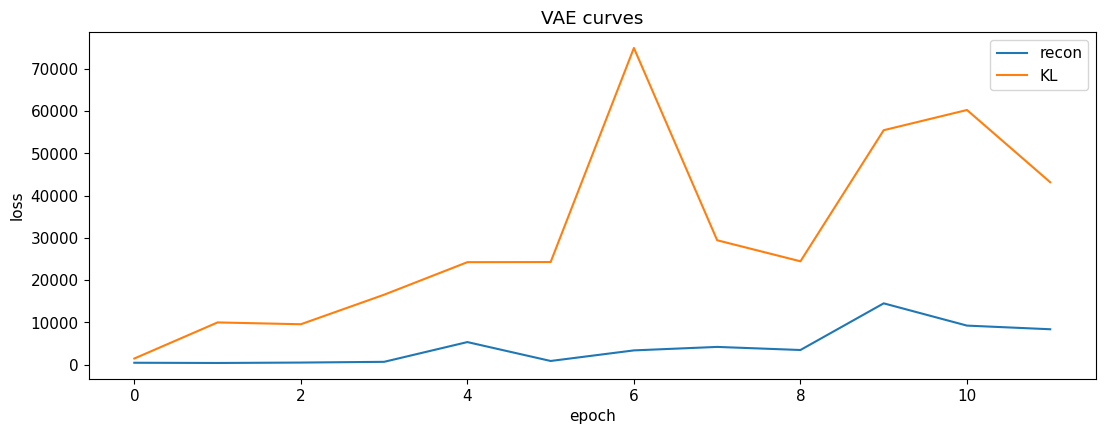

In [3]:
t0 = time.time()
hist = vae.fit(X_train, epochs=12, batch_size=1024, verbose=0)
t_train = time.time() - t0
print(f'Trained in {t_train:.1f}s | final loss {hist.history["loss"][-1]:.3f}')
plt.plot(hist.history['recon'], label='recon'); plt.plot(hist.history['kl'], label='KL')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('VAE curves'); plt.show()

## 3. Monte Carlo reconstruction probability and uncertainty

For each sample we draw $L$ realizations of the latent variable, decode each one,
and compute the weighted MSE. The **mean** across draws is the anomaly score; the
**standard deviation** quantifies the epistemic uncertainty of that alarm.

In [4]:
# per-feature weights (val AUC), following the NB04 recipe
mse_val0 = (X_val - vae.predict(X_val, batch_size=8192, verbose=0)) ** 2
aucs = np.array([roc_auc_score(y_val, mse_val0[:, j]) if len(np.unique(mse_val0[:, j])) > 1 else 0.5
                 for j in range(n_features)])
weights = np.maximum(aucs - 0.5, 0); weights = (weights / (weights.sum() + 1e-10)).astype('float32')

def mc_score(X, L=20, chunk=16384):
    mean_s = np.zeros(len(X)); m2 = np.zeros(len(X))
    for s in range(0, len(X), chunk):
        xb = X[s:s+chunk]
        mu, logvar = vae.encoder.predict(xb, batch_size=8192, verbose=0)
        logvar = np.clip(logvar, -LOGVAR_CLIP, LOGVAR_CLIP)
        acc = np.zeros((len(xb), L))
        for l in range(L):
            eps = np.random.normal(size=mu.shape).astype('float32')
            z = mu + np.exp(0.5 * logvar) * eps   # sample the latent
            rec = vae.decoder.predict(z, batch_size=8192, verbose=0)
            acc[:, l] = ((xb - rec) ** 2 * weights[None, :]).sum(1)
        mean_s[s:s+chunk] = acc.mean(1); m2[s:s+chunk] = acc.std(1)   # mean = score, std = uncertainty
    return mean_s, m2

t0 = time.time()
sv, _ = mc_score(X_val, L=20)
st, unc_test = mc_score(X_test, L=20)
print(f'MC scoring in {time.time()-t0:.1f}s')

thr, _ = C.calibrate_threshold(y_val, sv, beta=1.0)
yv = (sv > thr).astype(int); Wb, Kb = C.calibrate_WK(y_val, yv)
m = C.evaluate(y_test, st, thr, Wb, Kb)
print(f"VAE -> F1={m['f1']:.4f}  AUC-PR={m['auc_pr']:.4f}  P={m['precision']:.3f}  R={m['recall']:.3f}")

MC scoring in 24.8s
VAE -> F1=0.7152  AUC-PR=0.5453  P=0.694  R=0.738


## 4. Uncertainty as a triage tool

Mean uncertainty by distance to the threshold:
very close    20.5032
close         13.1309
medium         9.1791
far            4.9717
very far      76.7469
dtype: float64


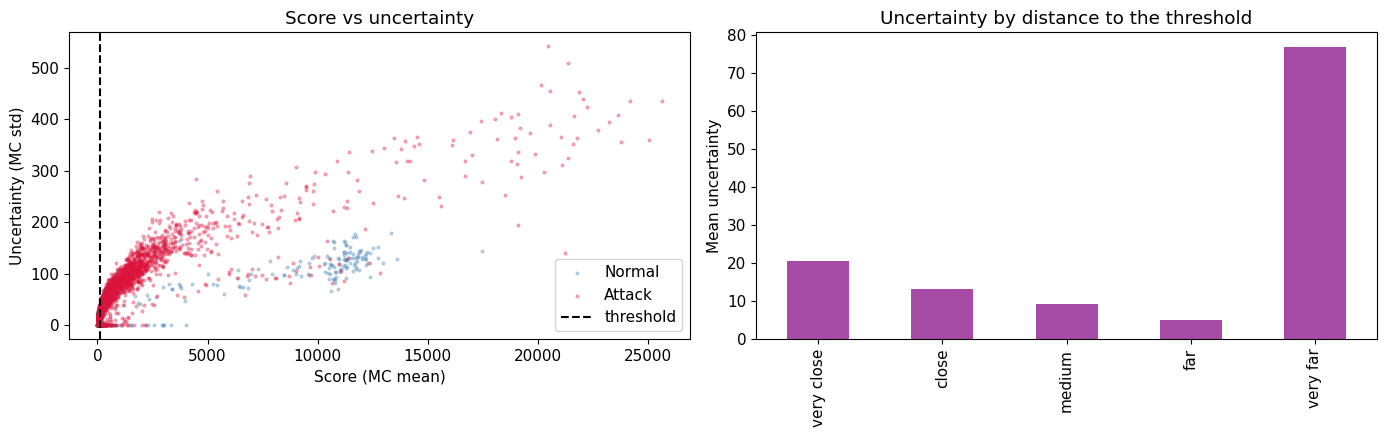

In [5]:
# uncertainty should peak near the threshold, in the zone of doubt
dist = np.abs(st - thr) / (st.std() + 1e-9)
bins = pd.qcut(dist, 5, labels=['very close','close','medium','far','very far'])
unc_by_bin = pd.Series(unc_test).groupby(bins).mean()
print('Mean uncertainty by distance to the threshold:')
print(unc_by_bin.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.scatter(st[y_test == 0][:4000], unc_test[y_test == 0][:4000], s=4, alpha=0.3, label='Normal', color='steelblue')
ax.scatter(st[y_test == 1][:4000], unc_test[y_test == 1][:4000], s=4, alpha=0.3, label='Attack', color='crimson')
ax.axvline(thr, color='k', ls='--', label='threshold')
ax.set(xlabel='Score (MC mean)', ylabel='Uncertainty (MC std)', title='Score vs uncertainty'); ax.legend()
ax = axes[1]
unc_by_bin.plot(kind='bar', ax=ax, color='purple', alpha=0.7)
ax.set(ylabel='Mean uncertainty', title='Uncertainty by distance to the threshold')
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'vae_uncertainty.png'), dpi=130); plt.show()

## 5. Probabilistic calibration (reliability diagram)

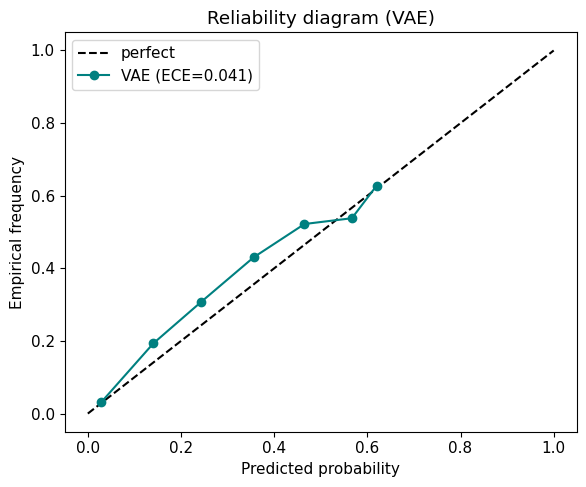

ECE = 0.0410


In [6]:
# map score -> probability with isotonic regression, fitted ONLY on val
iso = IsotonicRegression(out_of_bounds='clip').fit(sv, y_val)
p_test = iso.predict(st)
bins = np.linspace(0, 1, 11); idx = np.digitize(p_test, bins) - 1
emp, conf = [], []
for b in range(10):
    m_b = idx == b
    if m_b.sum() > 50:
        emp.append(y_test[m_b].mean()); conf.append(p_test[m_b].mean())
ece = np.mean(np.abs(np.array(emp) - np.array(conf)))   # expected calibration error
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', label='perfect')
ax.plot(conf, emp, 'o-', color='teal', label=f'VAE (ECE={ece:.3f})')
ax.set(xlabel='Predicted probability', ylabel='Empirical frequency',
       title='Reliability diagram (VAE)'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'vae_reliability.png'), dpi=130); plt.show()
print(f'ECE = {ece:.4f}')

## 6. Edge + saving

In [7]:
def predict_fn(X): return vae.predict(X, batch_size=8192, verbose=0)
ms, thr_put = C.edge_timing(predict_fn, X_test, n_repeat=3)
model_path = os.path.join(C.DATA_DIR, 'model_vae.keras')
try: vae.save(model_path); size_kb = os.path.getsize(model_path)/1e3
except Exception: size_kb = sum(w.nbytes for w in vae.get_weights())/1e3   # fall back to raw weight size

df_out = d['df_test'].copy()
df_out['vae_score'] = st; df_out['vae_uncertainty'] = unc_test
df_out['vae_prob'] = p_test
df_out[['vae_score', 'vae_uncertainty', 'vae_prob', 'label', 'attack_type', 'severity']].to_csv(
    os.path.join(C.DATA_DIR, 'predictions_vae.csv'))

lat = C.detection_latency(df_out.assign(p=C.temporal_vote((st > thr).astype(int), Wb, Kb)), 'p')
out = {'model': 'beta-VAE (reconstruction probability)', **{k: round(m[k], 4) for k in
        ['raw_f1','raw_precision','raw_recall','f1','f2','precision','recall','auc_roc','auc_pr']},
       'threshold': float(thr), 'temporal_W': Wb, 'temporal_K': Kb,
       'latent_dim': LATENT, 'beta': BETA, 'mc_samples': 20,
       'ece': round(float(ece), 4), 'mean_uncertainty': round(float(unc_test.mean()), 4),
       'model_size_kb': round(size_kb, 1), 'ms_per_sample': round(ms, 4),
       'n_params': int(vae.count_params()), 'train_time_s': round(t_train, 1),
       'detection_rate': round(float(lat['detected'].mean()), 4),
       'notes': 'Uncertainty via MC; isotonic calibration (val).'}
C.save_metrics('vae', out)
print('Saved: metrics_vae.json, predictions_vae.csv, model_vae.keras, vae_uncertainty.png, vae_reliability.png')
print(f"Edge: {size_kb:.1f} KB | {ms:.4f} ms/sample")

Saved: metrics_vae.json, predictions_vae.csv, model_vae.keras, vae_uncertainty.png, vae_reliability.png
Edge: 27.5 KB | 0.0003 ms/sample


## 7. Conclusions

- The VAE matches the Dense-AE on detection while **adding a new dimension**:
  every alarm carries a quantified **uncertainty**. High-uncertainty alarms
  cluster near the threshold — precisely where the operator should focus.
- **Calibration** (the reliability diagram and ECE) turns the raw score into an
  interpretable probability: "85% confidence" rather than an opaque yes/no.
- **Edge:** the model stays in the same size and latency class as the Dense-AE;
  the only added cost is the Monte Carlo sampling at inference time, which can be
  trimmed by reducing $L$.

> This directly addresses the "binary output without uncertainty" limitation
> flagged in the concluding chapter of the thesis.